In [2]:
from jaxcmr.simulation.activation import visualize_2d_array
from jaxcmr.memory import LinearAssociativeMcf, associate, probe
from jaxcmr.memorysearch import exponential_primacy_weighting
from jax import numpy as jnp, lax

In [3]:
item_count = 16
shared_support = 0.1
item_support = 0.9

primacy_weighting = exponential_primacy_weighting(10, 1., .1)
mcf = LinearAssociativeMcf.create(item_count, shared_support, item_support)
mcf = associate(
    mcf, 
    primacy_weighting[0], 
    jnp.eye(item_count + 2)[1], 
    jnp.eye(item_count)[5]
    )

mcf.state[:3]

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


Array([[0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. ],
       [0.9, 0.1, 0.1, 0.1, 0.1, 2.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
        0.1, 0.1, 0.1],
       [0.1, 0.9, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
        0.1, 0.1, 0.1]], dtype=float32)

In [4]:
probe(mcf, jnp.eye(item_count + 2)[1], 1.0)

Array([0.9, 0.1, 0.1, 0.1, 0.1, 2.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
       0.1, 0.1, 0.1], dtype=float32)

In [5]:
probe(mcf, jnp.eye(item_count + 2)[1], 3.0)

Array([7.8717209e-02, 1.0797975e-04, 1.0797975e-04, 1.0797975e-04,
       1.0797975e-04, 1.0000000e+00, 1.0797975e-04, 1.0797975e-04,
       1.0797975e-04, 1.0797975e-04, 1.0797975e-04, 1.0797975e-04,
       1.0797975e-04, 1.0797975e-04, 1.0797975e-04, 1.0797975e-04],      dtype=float32)

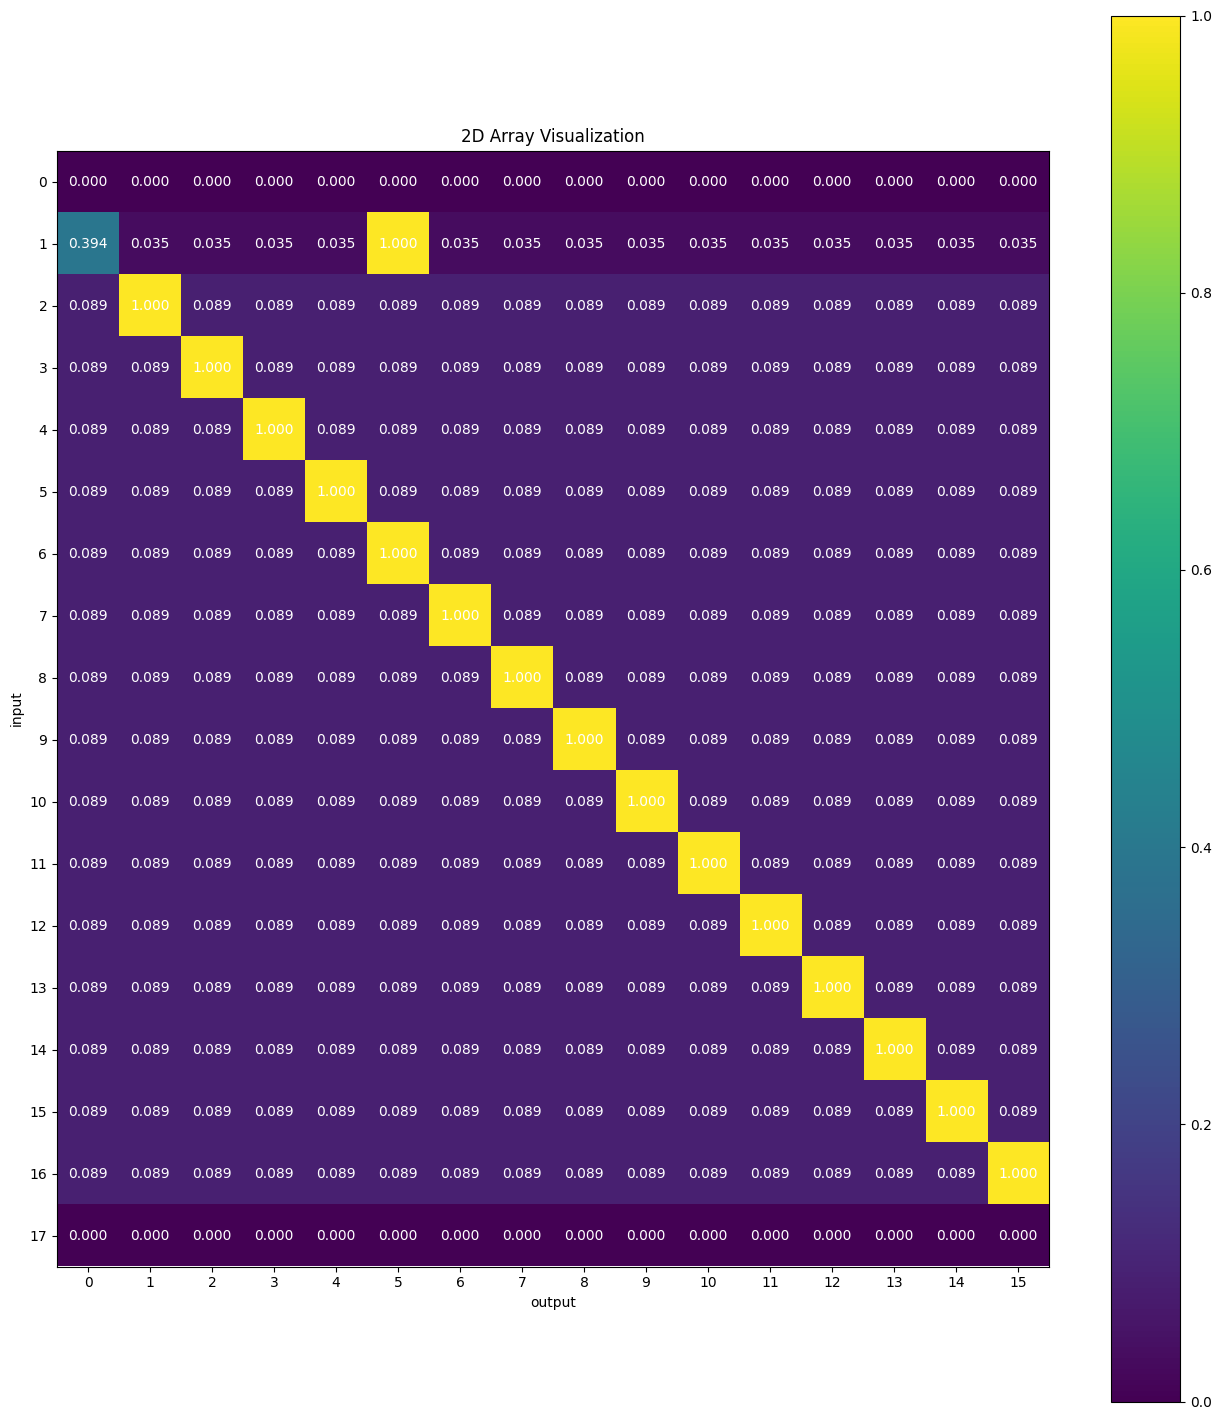

In [6]:
orthonormal_activation_matrix = lax.map(
    lambda _probe: probe(mcf, _probe, 1.1), 
    jnp.eye(mcf.state.shape[0])
    )

visualize_2d_array(orthonormal_activation_matrix)